# 1.8 肥尾分布与金融市场的极端风险

> **为什么高斯分布在金融中是危险假设？**
> 正态分布预测下，道琼斯指数单日下跌 20%（如1987年黑色星期一）的概率约为 $10^{-90}$，
> 相当于在宇宙年龄内也不应发生一次。但它真实发生了。
> 金融收益率是**肥尾分布**的——极端事件频率远超正态分布预测。

## 学习目标
- 理解肥尾（Fat Tails）和幂律分布的统计含义
- 用 QQ 图直观诊断收益率的非正态性
- 了解学生 t 分布在收益率建模中的优势
- 简介极值理论（EVT）及其在风险管理中的应用


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('Libraries loaded')


Libraries loaded


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 正态分布假设的危险：尾部概率对比

**峰度（Kurtosis）**是衡量尾部厚度的指标：
- 正态分布峰度 = 3（超额峰度 = 0）
- 实际金融数据超额峰度通常 > 3（肥尾）

超额峰度越大 → 极端事件（±3σ 以外）发生频率越高。


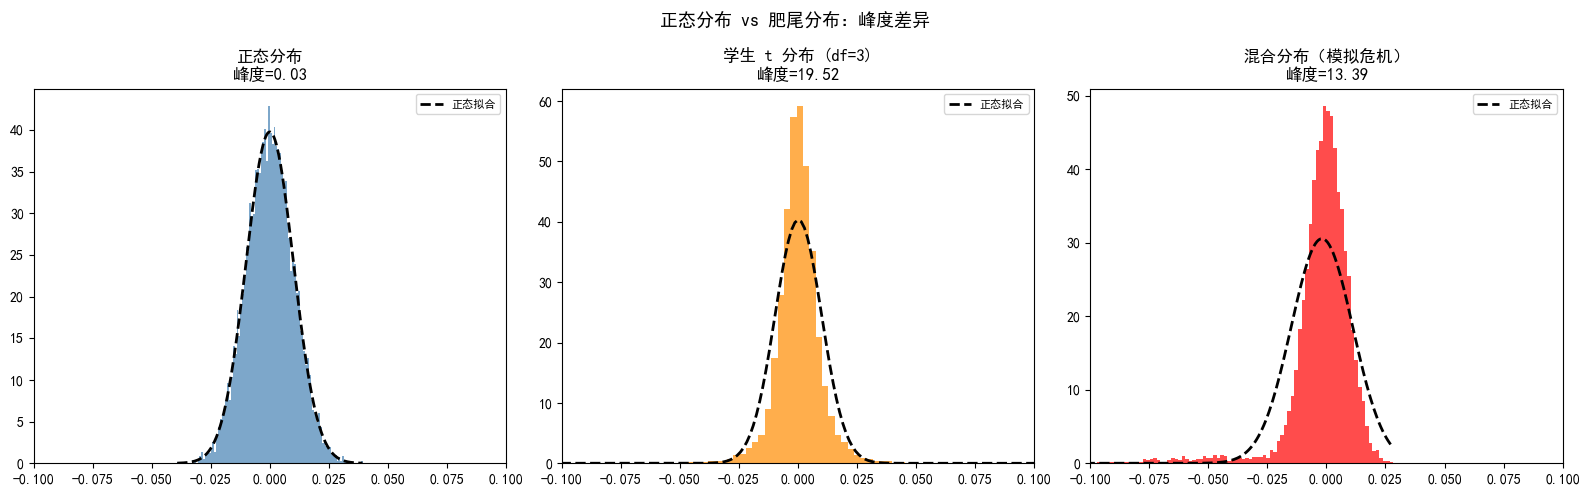

In [3]:
n = 10_000

# 正态分布（细尾）
normal_returns = np.random.normal(0, 0.01, n)

# 学生 t 分布（肥尾，自由度=3）
t_returns = np.random.standard_t(df=3, size=n) * 0.006

# 混合分布（模拟市场崩溃）：95% 正常 + 5% 危机
mixed = np.concatenate([
    np.random.normal(0, 0.008, int(n * 0.95)),
    np.random.normal(-0.04, 0.025, int(n * 0.05))
])
np.random.shuffle(mixed)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, data, title, color in zip(axes,
    [normal_returns, t_returns, mixed],
    ['正态分布', '学生 t 分布 (df=3)', '混合分布（模拟危机）'],
    ['steelblue', 'darkorange', 'red']):
    ax.hist(data, bins=100, density=True, alpha=0.7, color=color, edgecolor='none')
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, data.mean(), data.std()), 'k--', lw=2, label='正态拟合')
    ax.set_title(f'{title}\n峰度={stats.kurtosis(data):.2f}')
    ax.legend(fontsize=8); ax.set_xlim(-0.1, 0.1)
plt.suptitle('正态分布 vs 肥尾分布：峰度差异', fontsize=13)
plt.tight_layout(); plt.show()


## 2. QQ 图：直观诊断肥尾

如果数据服从正态分布，QQ 图应该是一条直线。肥尾数据在两端会向上/向下弯曲。


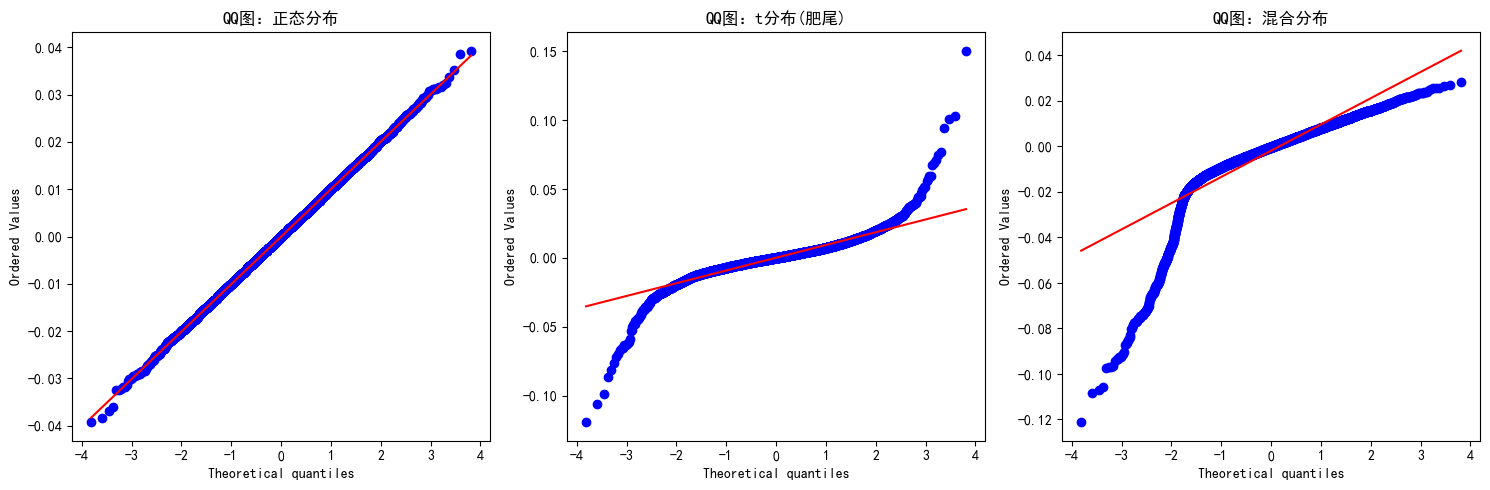

QQ 图判读：两端偏离红线越多，肥尾越严重


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, data, title in zip(axes,
    [normal_returns, t_returns, mixed],
    ['正态分布', 't分布(肥尾)', '混合分布']):
    stats.probplot(data, dist='norm', plot=ax)
    ax.set_title(f'QQ图：{title}')
    ax.get_lines()[1].set_color('red')
plt.tight_layout(); plt.show()
print('QQ 图判读：两端偏离红线越多，肥尾越严重')


## 3. 极端事件频率：正态 vs 现实

以日收益率标准差 σ=1% 为例，计算不同极端事件在各分布下的预测频率：


In [5]:
sigma = 0.01
print(f'日收益率标准差 σ = {sigma:.1%}\n')
print(f'{'事件':25s} {'正态分布理论频率':20s} {'t分布(df=5)频率':20s}')
print('-' * 65)

events = [(-0.03, '单日跌 3% (3σ)'), (-0.05, '单日跌 5% (5σ)'),
          (-0.10, '单日跌 10% (10σ)'), (-0.20, '单日跌 20% (20σ)')]

for threshold, label in events:
    z = threshold / sigma
    p_normal = stats.norm.cdf(z)
    p_t = stats.t.cdf(z, df=5)   # 自由度5的 t 分布
    freq_normal = f'1/{1/p_normal:.0e}'.replace('/', ' 年一次' if 1/p_normal > 250 else ' 天')
    years_normal = 1 / (p_normal * 252)
    years_t = 1 / (p_t * 252)
    print(f'{label:25s}  每 {years_normal:.1f} 年       每 {years_t:.1f} 年')


日收益率标准差 σ = 1.0%

事件                        正态分布理论频率             t分布(df=5)频率         
-----------------------------------------------------------------
单日跌 3% (3σ)                每 2.9 年       每 0.3 年
单日跌 5% (5σ)                每 13843.5 年       每 1.9 年
单日跌 10% (10σ)              每 520778282162624462848.0 年       每 46.4 年
单日跌 20% (20σ)              每 144110227007404368736004373587456829506024729208898486292676143949773087913817533317120.0 年       每 1374.2 年


## 4. 用学生 t 分布建模肥尾收益率


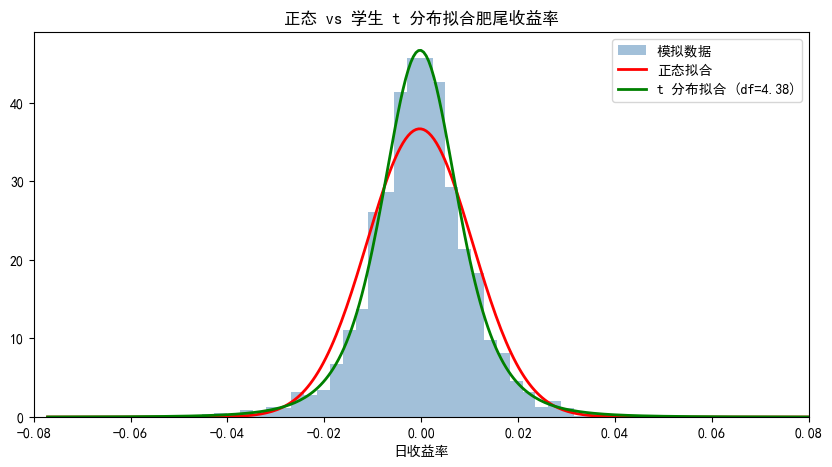

1% VaR (正态分布): -0.0256 (-2.56%)
1% VaR (t 分布):   -0.0291 (-2.91%)
t 分布的 VaR 更大（更保守），更接近极端市场的真实情况


In [6]:
# 用 MLE 拟合真实肥尾收益率
np.random.seed(42)
real_returns = np.random.standard_t(df=4, size=2000) * 0.008  # 模拟「真实」数据

# 拟合正态分布
norm_params = stats.norm.fit(real_returns)
# 拟合 t 分布
t_params = stats.t.fit(real_returns)  # (df, loc, scale)

x = np.linspace(real_returns.min(), real_returns.max(), 300)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(real_returns, bins=60, density=True, alpha=0.5, color='steelblue', label='模拟数据')
ax.plot(x, stats.norm.pdf(x, *norm_params), 'r-', lw=2, label=f'正态拟合')
ax.plot(x, stats.t.pdf(x, *t_params), 'g-', lw=2, label=f't 分布拟合 (df={t_params[0]:.2f})')
ax.set_xlim(-0.08, 0.08)
ax.legend(); ax.set_title('正态 vs 学生 t 分布拟合肥尾收益率')
ax.set_xlabel('日收益率'); plt.show()

# 比较尾部 VaR
alpha = 0.01  # 1% VaR
var_normal = stats.norm.ppf(alpha, *norm_params)
var_t = stats.t.ppf(alpha, *t_params)
print(f'1% VaR (正态分布): {var_normal:.4f} ({var_normal:.2%})')
print(f'1% VaR (t 分布):   {var_t:.4f} ({var_t:.2%})')
print(f't 分布的 VaR 更大（更保守），更接近极端市场的真实情况')


## 🎯 练习

1. 对 SPY/AAPL 真实历史日收益率进行 Jarque-Bera 正态性检验，输出峰度和 p 值。
2. 分别用 df=3、5、10、∞（正态）的 t 分布模拟 Monte Carlo，对比 1% CVaR 的差异。
3. 研究「极值理论 GEV」分布（scipy.stats.genextreme），对收益率最大回撤序列进行拟合。

---
**下一节** → `09_lln_clt.ipynb`